## analysing the changes in MSLP and winds post net zero using ACCESS net zero runs

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd


In [4]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [5]:
import cmocean
from scipy import stats

In [6]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [7]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [8]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [9]:
def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.7)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='/////', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 5
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.7)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='/////', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])

In [10]:
from functions import preproc_funcs as funcs

In [11]:
from functions import xr_lowess

### import data

In [12]:
psl_trans_orig = (xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_psl_original.nc').psl/100).load()
psl_trans = funcs.calc_anom(psl_trans_orig, psl_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [13]:
uas_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_uas_original.nc').load()
uas_trans = funcs.calc_anom(uas_trans_orig, uas_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [14]:
vas_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_vas_original.nc').load()
vas_trans = funcs.calc_anom(vas_trans_orig, vas_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [15]:
# psl_pic_orig = xr.open_dataset('/g/data/if69/as8561/data/piControl_data/psl_pic.nc').sel(model = 'ACCESS-ESM1-5').load()

In [16]:
psl_stable_orig = (xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_psl.nc').psl/100).load()
psl_stable = funcs.calc_anom(psl_stable_orig, psl_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [17]:
was_stable_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_was.nc').load()

/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.10/lib/python3.9/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [18]:
uas_stable = was_stable_orig.uas
vas_stable = was_stable_orig.vas

uas_stable = funcs.calc_anom(was_stable_orig.uas, uas_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))
vas_stable = funcs.calc_anom(was_stable_orig.vas, vas_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [19]:
weights_model = np.cos(np.deg2rad(psl_trans.lat))

In [20]:
# plot_list = [
#     (psl_trans.psl/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
#     (psl_trans.psl/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
#     (psl_trans.psl/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
# ]

plot_list = [
    (psl_trans).sel(lat = slice(-90, 20)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
    (psl_trans).sel(lat = slice(-90, 20)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
    (psl_trans).sel(lat = slice(-90, 20)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
]

In [21]:
uwnd_list = [
    (uas_trans.uas).sel(lat = slice(-90, 20)).sel(time = slice('2045', '2075')).mean(('model', 'time')).to_numpy(),
    (uas_trans.uas).sel(lat = slice(-90, 20)).sel(time = slice('2030', '2060')).mean(('model', 'time')).to_numpy(),
    (uas_trans.uas).sel(lat = slice(-90, 20)).sel(time = slice('2015', '2045')).mean(('model', 'time')).to_numpy(),
]

In [22]:
vwnd_list = [
    (vas_trans.vas).sel(lat = slice(-90, 20)).sel(time = slice('2045', '2075')).mean(('model', 'time')).to_numpy(),
    (vas_trans.vas).sel(lat = slice(-90, 20)).sel(time = slice('2030', '2060')).mean(('model', 'time')).to_numpy(),
    (vas_trans.vas).sel(lat = slice(-90, 20)).sel(time = slice('2015', '2045')).mean(('model', 'time')).to_numpy(),
]

In [23]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [26]:
contour_data = [
    (psl_trans_orig).sel(lat = slice(-90, 20)).sel(time = slice('1850', '1900')).mean(('model', 'time')) - 1000,
    (psl_trans_orig).sel(lat = slice(-90, 20)).sel(time = slice('1850', '1900')).mean(('model', 'time')) - 1000,
    (psl_trans_orig).sel(lat = slice(-90, 20)).sel(time = slice('1850', '1900')).mean(('model', 'time')) - 1000,
]

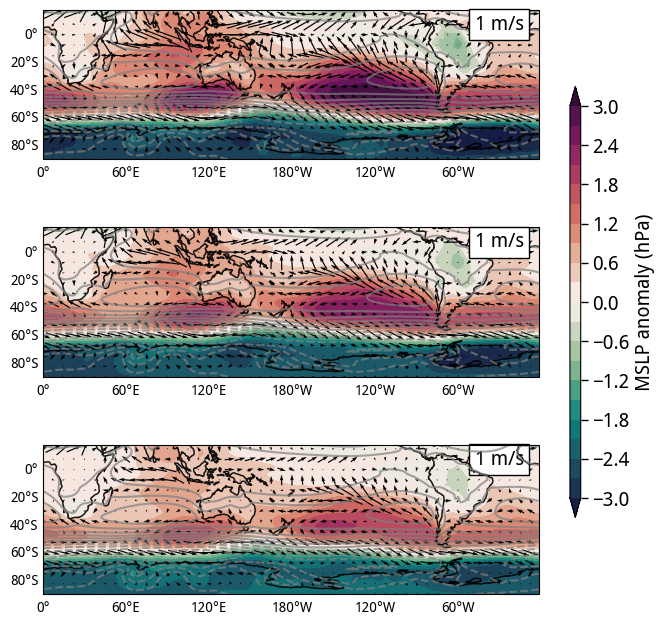

In [36]:
plot_maps(xx, yy, plot_list, ['']*3, ['']*3, cmap=cmocean.cm.curl, levels = np.linspace(-3, 3, 21), pval = [], draw_winds=True, u_wnd=uwnd_list, v_wnd=vwnd_list, wind_scale=24, draw_contour=True, contour_data=contour_data, contour_levels=np.linspace(-20, 20, 11), contour_colors='tab:gray', 
            nrows=3, ncols=1, figsize=(8,8), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='MSLP anomaly (hPa)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)


In [28]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [29]:
stable_plot_list = [
    additional_sampling_stabilisation((psl_stable).sel(model = 'B2060').sel(lat = slice(-90, 20)).sel(time = slice('2060', '3060'))).mean(('model')),
    additional_sampling_stabilisation((psl_stable).sel(model = 'B2045').sel(lat = slice(-90, 20)).sel(time = slice('2045', '3045'))).mean(('model')),
    additional_sampling_stabilisation((psl_stable).sel(model = 'B2030').sel(lat = slice(-90, 20)).sel(time = slice('2030', '3030'))).mean(('model')),
]

Done
Done
Done


In [30]:
stable_uwnd_list = [
    additional_sampling_stabilisation((uas_stable.uas).sel(model = 'B2060').sel(lat = slice(-90, 20)).sel(time = slice('2060', '3060'))).mean(('model')).to_numpy(),
    additional_sampling_stabilisation((uas_stable.uas).sel(model = 'B2045').sel(lat = slice(-90, 20)).sel(time = slice('2045', '3045'))).mean(('model')).to_numpy(),
    additional_sampling_stabilisation((uas_stable.uas).sel(model = 'B2030').sel(lat = slice(-90, 20)).sel(time = slice('2030', '3030'))).mean(('model')).to_numpy(),
]

Done
Done
Done


In [31]:
stable_vwnd_list = [
    additional_sampling_stabilisation((vas_stable.vas).sel(model = 'B2060').sel(lat = slice(-90, 20)).sel(time = slice('2060', '3060'))).mean(('model')).to_numpy(),
    additional_sampling_stabilisation((vas_stable.vas).sel(model = 'B2045').sel(lat = slice(-90, 20)).sel(time = slice('2045', '3045'))).mean(('model')).to_numpy(),
    additional_sampling_stabilisation((vas_stable.vas).sel(model = 'B2030').sel(lat = slice(-90, 20)).sel(time = slice('2030', '3030'))).mean(('model')).to_numpy(),
]

Done
Done
Done


In [32]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

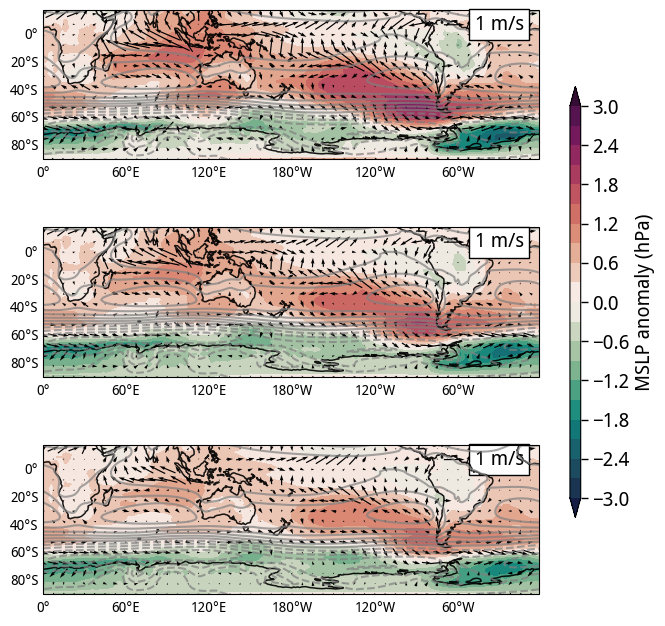

In [37]:
plot_maps(xx, yy, stable_plot_list, ['']*3, ['']*3, cmap=cmocean.cm.curl, levels = np.linspace(-3, 3, 21), pval = [], draw_winds=True, u_wnd=stable_uwnd_list, v_wnd=stable_vwnd_list, wind_scale=24, draw_contour=True, contour_data=contour_data, contour_levels=np.linspace(-20, 20, 11), contour_colors='tab:gray', 
            nrows=3, ncols=1, figsize=(8,8), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='MSLP anomaly (hPa)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)


In [112]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [40]:
pval_list = [
    funcs.mannwhitneyu3d((psl_trans).sel(lat = slice(-90, 20)).mean(('time')), additional_sampling_stabilisation((psl_stable).sel(model = 'B2060').sel(lat = slice(-90, 20)).sel(time = slice('2060', '3060'))), dim='model'),
    funcs.mannwhitneyu3d((psl_trans).sel(lat = slice(-90, 20)).mean(('time')), additional_sampling_stabilisation((psl_stable).sel(model = 'B2045').sel(lat = slice(-90, 20)).sel(time = slice('2045', '3045'))), dim='model'),
    funcs.mannwhitneyu3d((psl_trans).sel(lat = slice(-90, 20)).mean(('time')), additional_sampling_stabilisation((psl_stable).sel(model = 'B2030').sel(lat = slice(-90, 20)).sel(time = slice('2030', '3030'))), dim='model'),
]

Done
Done
Done


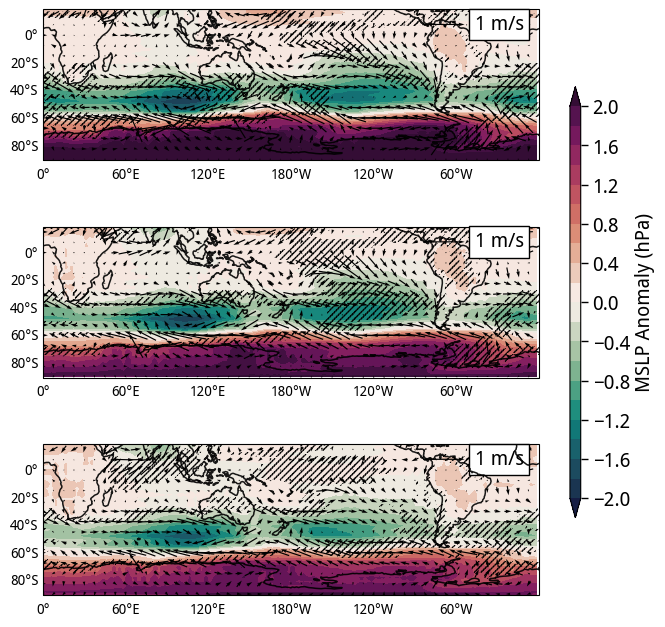

In [42]:
plot_maps(xx, yy, np.array(stable_plot_list) - np.array(plot_list), ['']*3, ['']*3, cmap=cmocean.cm.curl, levels = np.linspace(-2.0, 2.0, 21), pval = pval_list, draw_winds=True, u_wnd=(np.array(stable_uwnd_list) - np.array(uwnd_list)), v_wnd=(np.array(stable_vwnd_list) - np.array(vwnd_list)), \
            wind_scale=12, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='tab:gray', 
            nrows=3, ncols=1, figsize=(8,8), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='MSLP Anomaly (hPa)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)